In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import pylatexenc


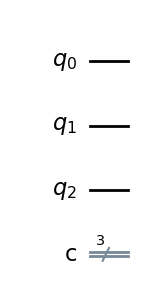

In [2]:
# Creamos los registros
nqr = 3#numero de registros cuanticos
ncr = 3#numero de registros clasicos

# Cuántico, serán nuestros qubits
qr = QuantumRegister(nqr, name='q')

# Clásico, nuestros registros de medida
cr = ClassicalRegister(ncr, name='c')

# Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')

#Dibujamos el circuito: mpl para dibujarlo con matplotlib, sin ello sale feo
qc.draw('mpl')

# Añadir Puertas

Vamos a añadir diferentes puertas al circuito.

Hay que tener en mente que el circuito qc es un objeto, por lo que si vuelves a ejecutar esta celda, irás añadiendo las puertas de nuevo una y otra vez

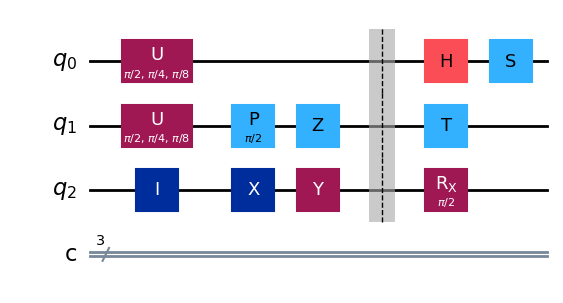

In [4]:
# Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')

#Añadimos una puerta de cada tipo single-qubit
#General
qc.u(np.pi/2, np.pi/4, np.pi/8, qr[0:2])#Parámetros y qubit a los que aplicarlo
#Fase
qc.p(np.pi/2,qr[1])
#Identidad
qc.id(qr[2])
#Pauli X
qc.x(qr[2])
#Pauli Y
qc.y(qr[2])
#Pauli Z
qc.z(qr[1])
#Barrera
qc.barrier(range(nqr))
#Hadamard
qc.h(qr[0])
#S
qc.s(qr[0])#sdg el dagger
#T
qc.t(qr[1])#tdg el dagger
#Rx 
qc.rx(np.pi/2,qr[2])

qc.draw('mpl')

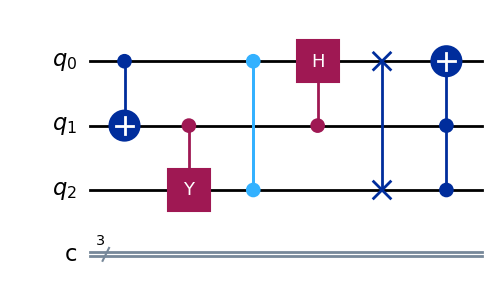

In [6]:
# Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')

#Multigates
#CNOT
qc.cx(qr[0], qr[1])#Condicionante, condicionado
#C-Y
qc.cy(qr[1], qr[2])#Condicionante, condicionado
#C-Z
qc.cz(qr[2], qr[0])#Condicionante, condicionado, aunque aquí da igual
#C-H
qc.ch(qr[1], qr[0])#Condicionante, condicionado
#SWAP
qc.swap(qr[2], qr[0])
#Toffoli
qc.ccx(qr[1], qr[2], qr[0])#Condicionante, condicionante, condicionado


qc.draw('mpl')

# Medición

Ahora mediremos los qubits

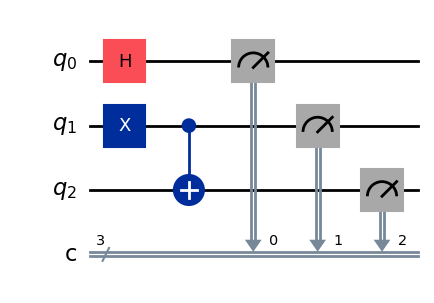

In [7]:
# Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')

qc.h(0)
qc.x(1)
qc.cx(1,2)

#Medimos todos los qubits en todos los registros clásicos
qc.measure(qr, cr)

qc.draw('mpl')

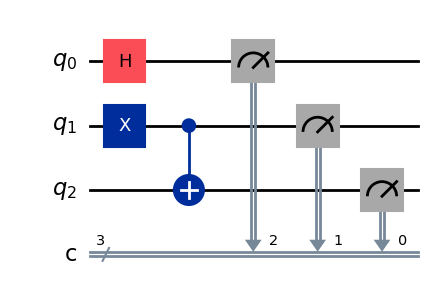

In [8]:
# Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')

qc.h(0)
qc.x(1)
qc.cx(1,2)

#Medimos todos los qubits en todos los registros clásicos
qc.measure(qr, cr[::-1])  # [::-1] cambia el orden de guardado

qc.draw('mpl')

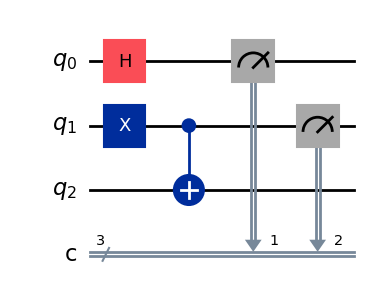

In [10]:
# Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')

qc.h(0)
qc.x(1)
qc.cx(1,2)

#Podemos medir en solo ciertos qubits
qc.measure(qr[0:2], cr[1:])  # Hasta podemos hacer que las salidas se realicen en otro orden

qc.draw('mpl')

# Inicialización

Podemos inicializar un estado normalizado arbitrario (aunque nadie dice que sea eficiente o exacto)

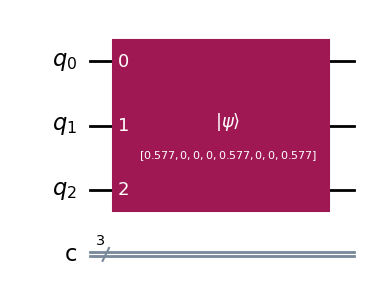

In [11]:
#Componentes de la inicialización
vector = [ 1/np.sqrt(3), 0, 0, 0,
          1/np.sqrt(3), 0, 0, 1/np.sqrt(3)]

#Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')

#Inicializamos 
qc.initialize(vector, [qr[0], qr[1], qr[2]])

qc.draw('mpl')

# Ejecución

Vamos a ejecutar nuestro circuito en un simulador

In [13]:
from qiskit import transpile
from qiskit_aer import AerSimulator
backend = AerSimulator()#Obtenemos nuestro simulador

In [27]:
#Circuito cuántico
qc = QuantumCircuit(qr, cr, name='quantum circuit')
qc.h(0)
qc.x(1)
qc.cx(1,2)

#Medimos todos los qubits en todos los registros clásicos
qc.measure(qr, cr)

#Transpilamos y ejecutamos
# Transpilar = Adecuar el circuito cuántico a los componentes del simulador/ordenador cuántico
job = backend.run(transpile(qc, backend), shots=2000)#Shots es el número de ejecuciones
#También se puede usar job = execute(qc, backend, shots=2000)

In [28]:
#obtenemos el diccionario de resultados y sus cuentas
result = job.result()
counts = result.get_counts(qc)
print(counts)

{'110': 985, '111': 1015}


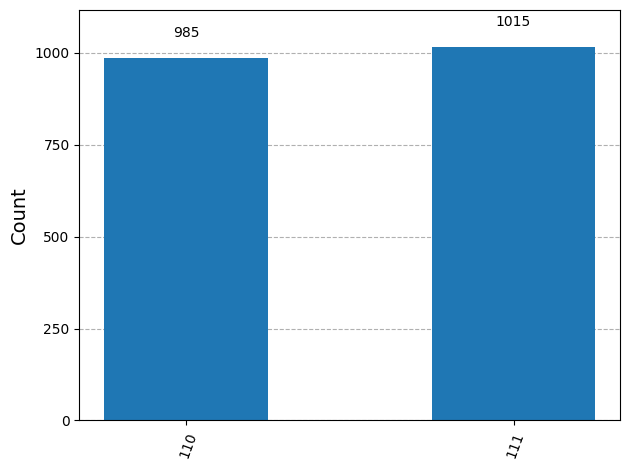

In [29]:
#Los ploteamos
from qiskit.visualization import plot_histogram
plot_histogram(counts)

Para más:

https://www.youtube.com/watch?v=RXfmP7eaV5s

https://youtu.be/qxuTMeO69t8